In [196]:
!pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import sqlite3
import os
import seaborn  as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FuncFormatter

# 1. Read the data

In [197]:
df_raw = pd.read_csv('/Users/ying/Downloads/QVI_data.csv')

In [198]:
df = df_raw.copy()
df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget


In [199]:
# check data types and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [200]:
# change data type of date column to datetime
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')

# check if date is continuous
date_range = pd.date_range(start=df['DATE'].min(), end=df['DATE'].max())
missing_dates = date_range.difference(df['DATE'])
print(f'Missing dates: {missing_dates}')


Missing dates: DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')


# Step 2: Exploratory Data Analysis (EDA)

In [201]:
# 1. create month column
df['MONTH'] = df['DATE'].dt.to_period('M')
df['MONTH'] = df['MONTH'].dt.to_timestamp()

# 2. Key KPIs:

# total customers
total_customers_count = df['LYLTY_CARD_NBR'].nunique()
print('total_customers_count is: ', total_customers_count)

# Key KPIs by month
monthly_summary = df.groupby('MONTH').agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'nunique'
}).reset_index().rename(columns={
    'TOT_SALES': 'TOTAL_SALES',
    'LYLTY_CARD_NBR': 'UNIQUE_CUSTOMERS',
    'TXN_ID': 'TXN_COUNT'
})

# 3. calculate average sales per customer and average price per unit, average transaction per customer, average price per unit, average number of chips per customer
monthly_summary['AVG_SALES_PER_CUSTOMER'] = (monthly_summary['TOTAL_SALES'] / monthly_summary['UNIQUE_CUSTOMERS']).round(2)
monthly_summary['AVG_PRICE_PER_UNIT'] = (monthly_summary['TOTAL_SALES'] / df.groupby('MONTH')['PROD_QTY'].sum().values).round(2)
monthly_summary['AVG_TXN_PER_CUSTOMER'] = (monthly_summary['TXN_COUNT'] / monthly_summary['UNIQUE_CUSTOMERS']).round(2)
monthly_summary['AVG_CHIPS_PER_CUSTOMER'] = (df.groupby('MONTH')['PROD_QTY'].sum().values / monthly_summary['UNIQUE_CUSTOMERS']).round(2)
display(monthly_summary)


total_customers_count is:  72636


,MONTH,TOTAL_SALES,UNIQUE_CUSTOMERS,TXN_COUNT,AVG_SALES_PER_CUSTOMER,AVG_PRICE_PER_UNIT,AVG_TXN_PER_CUSTOMER,AVG_CHIPS_PER_CUSTOMER
0,2018-07-01,165275.30,18780,22435,8.80,3.82,1.19,2.30
1,2018-08-01,158081.05,18718,22264,8.45,3.83,1.19,2.21
2,2018-09-01,160522.00,18191,21593,8.82,3.84,1.19,2.30
3,2018-10-01,164415.70,18570,22157,8.85,3.84,1.19,2.31
4,2018-11-01,160233.70,18299,21710,8.76,3.82,1.19,2.29
5,2018-12-01,167913.40,19076,22683,8.80,3.83,1.19,2.30
6,2019-01-01,162642.30,18463,22000,8.81,3.83,1.19,2.30
7,2019-02-01,150665.00,17249,20266,8.73,3.84,1.17,2.27
8,2019-03-01,166265.20,18897,22447,8.80,3.84,1.19,2.29
9,2019-04-01,159845.10,18164,21637,8.80,3.82,1.19,2.30


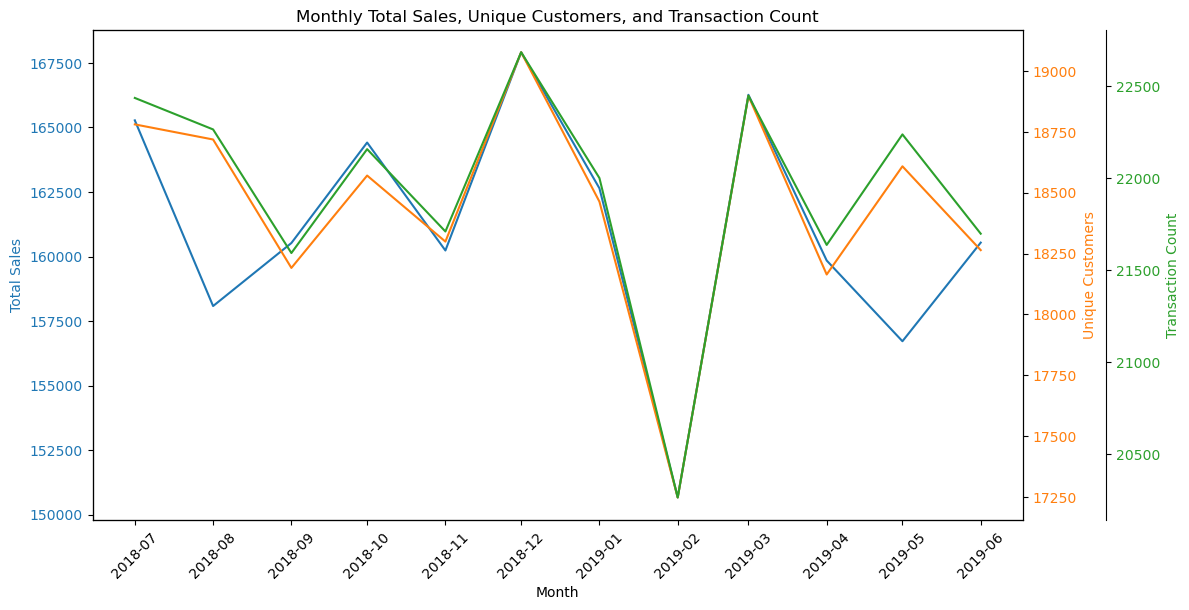

In [202]:
# 3. Data Visualization

# a. three line charts of total sales, unique customers, and transaction count over time with separate y-axes, 
# and the x-axis should be the month with intervals of 1 month.
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales', color='tab:blue')
ax1.plot(monthly_summary['MONTH'], monthly_summary['TOTAL_SALES'], color='tab:blue', label='Total Sales')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.set_ylabel('Unique Customers', color='tab:orange')
ax2.plot(monthly_summary['MONTH'], monthly_summary['UNIQUE_CUSTOMERS'], color='tab:orange', label='Unique Customers')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Transaction Count', color='tab:green')
ax3.plot(monthly_summary['MONTH'], monthly_summary['TXN_COUNT'], color='tab:green', label='Transaction Count')
ax3.tick_params(axis='y', labelcolor='tab:green')
fig.tight_layout()
plt.title('Monthly Total Sales, Unique Customers, and Transaction Count')
plt.show()

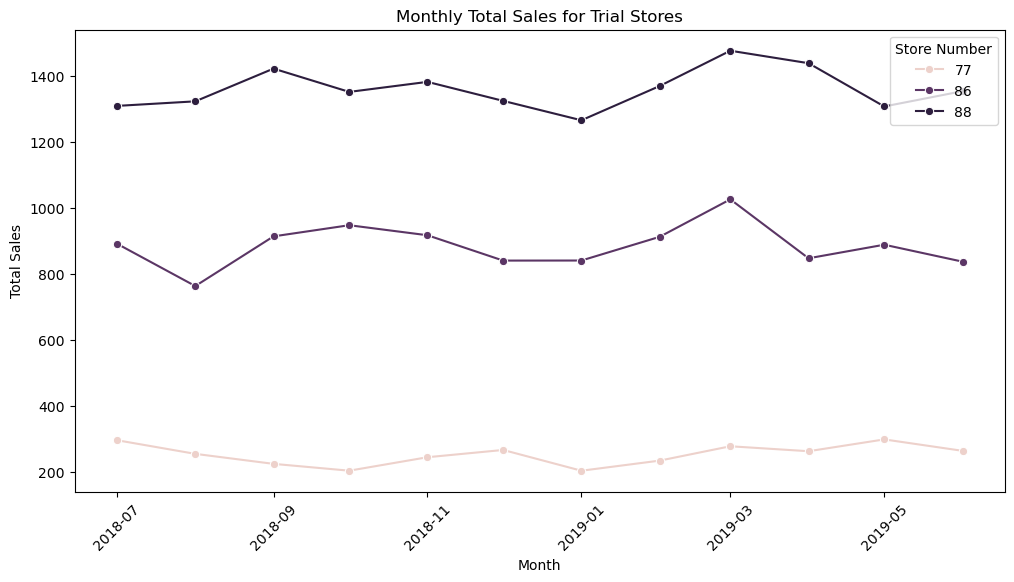

In [203]:
# b. see the trial store's performance over time, and the trial store are store 77, store 86, store 88.
trial_stores = [77, 86, 88]
trial_store_data = df[df['STORE_NBR'].isin(trial_stores)].groupby(['MONTH', 'STORE_NBR'])['TOT_SALES'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=trial_store_data, x='MONTH', y='TOT_SALES', hue='STORE_NBR', marker='o')
plt.title('Monthly Total Sales for Trial Stores')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Store Number')
plt.show()

# Step 3: standardised correlation metric between trial store and control stores

In [204]:
# a. calculate a standardised metric based on the absolute difference between the trial store's performance and each control store's performance
def calculate_standardized_metric(trial_store, control_store):
    trial_data = df[df['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum()
    control_data = df[df['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum()
    absolute_difference = abs(trial_data - control_data)
    standardized_metric = absolute_difference / trial_data
    return standardized_metric.mean()  # Return the average standardized metric over the months
standardized_metrics = {}
for trial_store in trial_stores:
    for control_store in control_stores:
        standardized_metric = calculate_standardized_metric(trial_store, control_store)
        standardized_metrics[(trial_store, control_store)] = standardized_metric
standardized_metric_df = pd.DataFrame(standardized_metrics.items(), columns=['Store_Pair', 'Standardized_Metric'])
standardized_metric_df[['Trial_Store', 'Control_Store']] = pd.DataFrame(standardized_metric_df['Store_Pair'].tolist(), index=standardized_metric_df.index)
standardized_metric_df.drop(columns=['Store_Pair'], inplace=True)
standardized_metric_df = standardized_metric_df[['Trial_Store', 'Control_Store', 'Standardized_Metric']]
standardized_metric_df['Rank'] = standardized_metric_df.groupby('Trial_Store')['Standardized_Metric'].rank(ascending=True)
top_control_stores_standardized = standardized_metric_df[standardized_metric_df['Rank'] <= 5]
print(top_control_stores_standardized)


     Trial_Store  Control_Store  Standardized_Metric  Rank
45            77             46             0.113851   1.0
183           77            187             0.137256   5.0
184           77            188             0.135815   4.0
210           77            214             0.123753   2.0
229           77            233             0.133299   3.0
330           86             62             0.073923   5.0
353           86            155             0.046854   1.0
363           86             97             0.072123   4.0
375           86            109             0.057924   3.0
494           86            229             0.055571   2.0
577           88             40             0.067697   1.0
699           88            165             0.089281   3.0
733           88            199             0.092347   4.0
760           88            226             0.107470   5.0
771           88            237             0.075658   2.0


### For trial store 77, the top 5 control stores based on the standardized metric are 233, 214, 188, 187, and 46.

before intervention 77 vs control 233 sales correlation: 0.904
average percentage difference before intervention: 8.03%


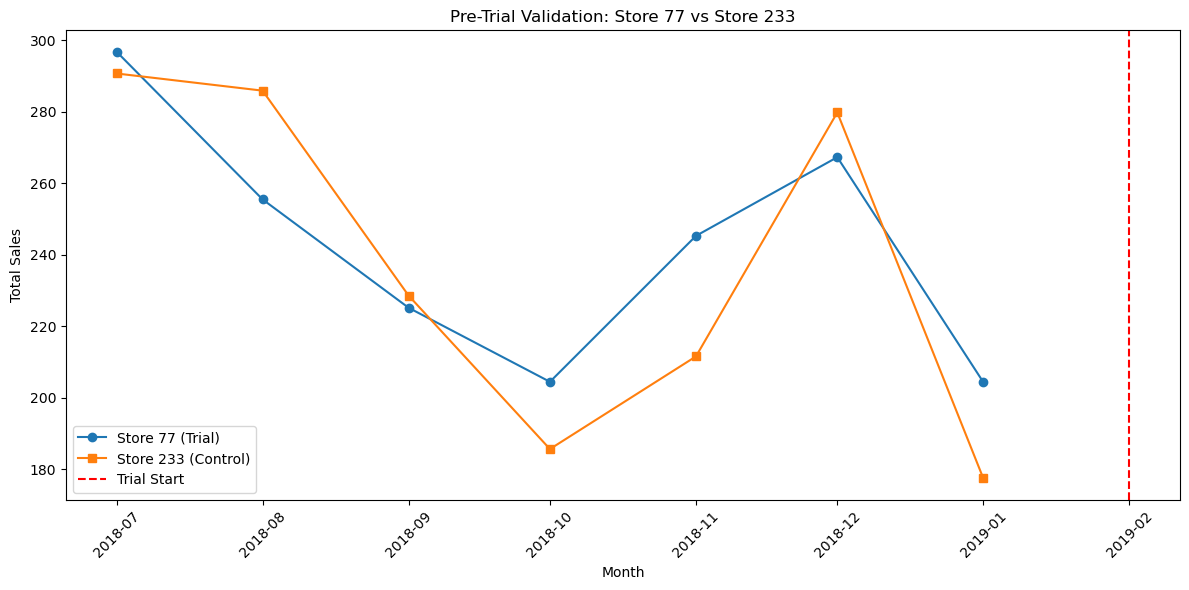

In [205]:
# Assume the trial store is 77, and you select the control store ranked first in the standardized metric (for example, 46,187,188,214,233).
trial_store = 77
control_store = 233 # tried five times from the top control stores ranked by standardized metric, 233 is the best one with the smallest standardized metric

# Filter pre-intervention data (assuming intervention starts from February 2019)
pre_trial_start = '2018-07-01'
pre_trial_end = '2019-01-31'

# Extract the monthly sales of the trial store and control store before the intervention
pre_data = df[(df['DATE'] >= pre_trial_start) & (df['DATE'] <= pre_trial_end)]
pre_trial = pre_data[pre_data['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
pre_control = pre_data[pre_data['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

# merge the trial and control data on MONTH
pre_merged = pd.merge(pre_trial, pre_control, on='MONTH', suffixes=('_trial', '_control'))

# Calculate correlation and percentage difference
correlation = pre_merged['TOT_SALES_trial'].corr(pre_merged['TOT_SALES_control'])
pre_merged['pct_diff'] = abs(pre_merged['TOT_SALES_trial'] - pre_merged['TOT_SALES_control']) / pre_merged['TOT_SALES_trial'] * 100
avg_pct_diff = pre_merged['pct_diff'].mean()

print(f"before intervention {trial_store} vs control {control_store} sales correlation: {correlation:.3f}")
print(f"average percentage difference before intervention: {avg_pct_diff:.2f}%")

# plot for validation
plt.figure(figsize=(12, 6))
plt.plot(pre_merged['MONTH'], pre_merged['TOT_SALES_trial'], marker='o', label=f'Store {trial_store} (Trial)')
plt.plot(pre_merged['MONTH'], pre_merged['TOT_SALES_control'], marker='s', label=f'Store {control_store} (Control)')
plt.axvline(x=pd.to_datetime('2019-02-01'), color='red', linestyle='--', label='Trial Start')
plt.title(f'Pre-Trial Validation: Store {trial_store} vs Store {control_store}')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average monthly absolute uplift after intervention: $34.78
Average monthly relative uplift after intervention: 21.80%


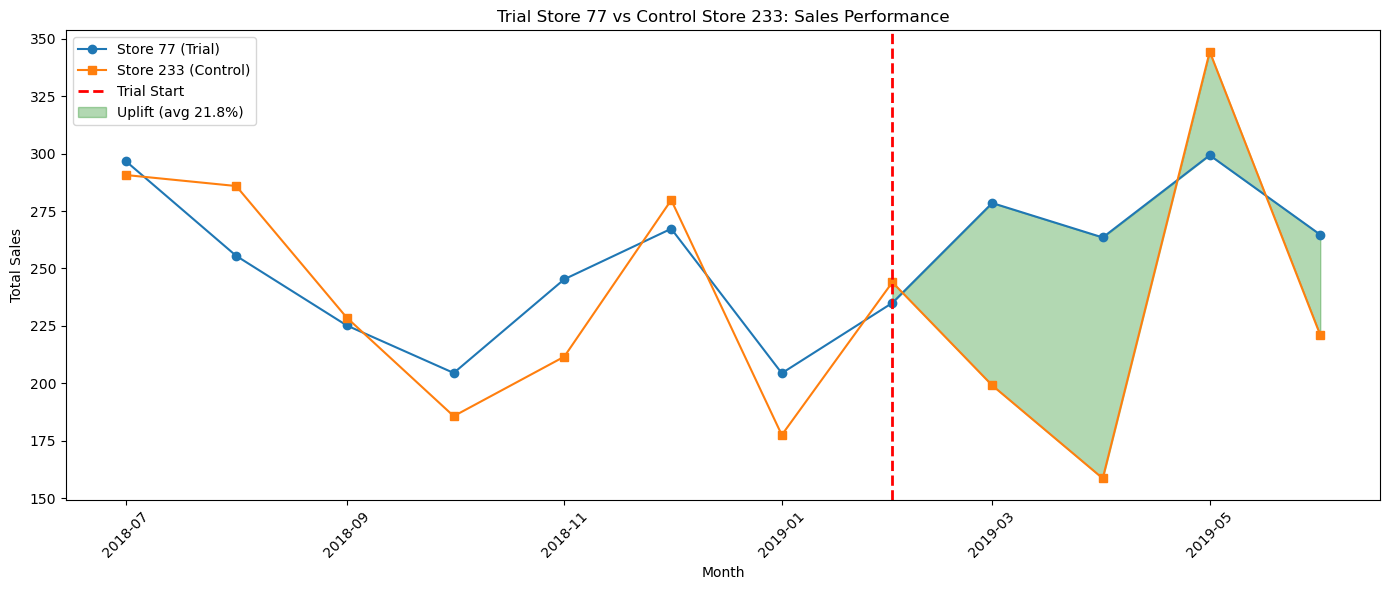

In [206]:
# 2. validate the performance
# filter post-intervention data (February 2019 and later)
post_trial_start = '2019-02-01'
post_trial_end = '2019-06-30'

post_data = df[(df['DATE'] >= post_trial_start) & (df['DATE'] <= post_trial_end)]
post_trial = post_data[post_data['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
post_control = post_data[post_data['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

# merge the post-intervention data
post_merged = pd.merge(post_trial, post_control, on='MONTH', suffixes=('_trial', '_control'))

# calculate Uplift (absolute and percentage)
post_merged['uplift_abs'] = post_merged['TOT_SALES_trial'] - post_merged['TOT_SALES_control']
post_merged['uplift_pct'] = (post_merged['uplift_abs'] / post_merged['TOT_SALES_control']) * 100

# calculate average Uplift
avg_uplift_pct = post_merged['uplift_pct'].mean()
avg_uplift_abs = post_merged['uplift_abs'].mean()

print(f"Average monthly absolute uplift after intervention: ${avg_uplift_abs:.2f}")
print(f"Average monthly relative uplift after intervention: {avg_uplift_pct:.2f}%")

# plot the full-period comparison chart (including pre- and post-intervention)
full_trial = df[df['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
full_control = df[df['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(full_trial['MONTH'], full_trial['TOT_SALES'], marker='o', label=f'Store {trial_store} (Trial)')
plt.plot(full_control['MONTH'], full_control['TOT_SALES'], marker='s', label=f'Store {control_store} (Control)')
plt.axvline(x=pd.to_datetime('2019-02-01'), color='red', linestyle='--', linewidth=2, label='Trial Start')
plt.fill_between(post_merged['MONTH'], 
                  post_merged['TOT_SALES_control'], 
                  post_merged['TOT_SALES_trial'], 
                  alpha=0.3, color='green', label=f'Uplift (avg {avg_uplift_pct:.1f}%)')
plt.title(f'Trial Store {trial_store} vs Control Store {control_store}: Sales Performance')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [207]:
# 3. Check the significance of the uplift using a simple t-test comparing the pre-intervention and post-intervention sales differences between the trial and control stores.

# T-test for pre- and post-intervention differences

# Difference before intervention
pre_diff = pre_merged['TOT_SALES_trial'] - pre_merged['TOT_SALES_control']

# Difference after intervention
post_diff = post_merged['TOT_SALES_trial'] - post_merged['TOT_SALES_control']

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(pre_diff, post_diff)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The difference before and after the intervention is significant, indicating the new layout is effective")
else:
    print("Conclusion: The difference before and after the intervention is not significant, so we cannot prove the new layout is effective")

t-statistic: -1.162
p-value: 0.2724
Conclusion: The difference before and after the intervention is not significant, so we cannot prove the new layout is effective


### For trial store 86

before intervention 86 vs control 155 sales correlation: 0.878
average percentage difference before intervention: 3.67%


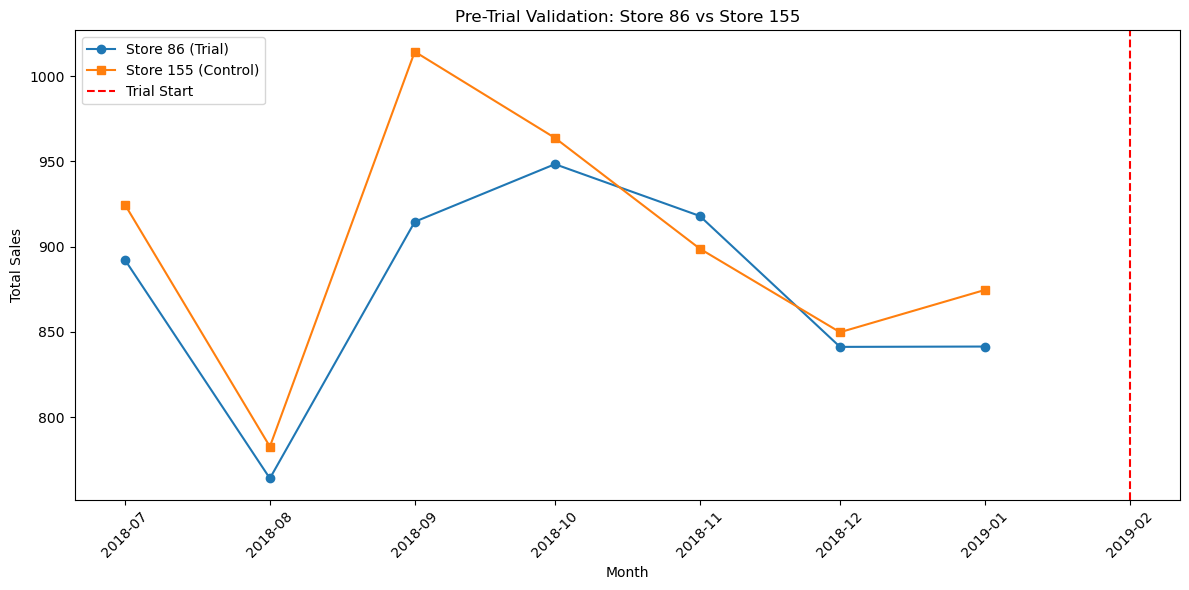

In [208]:
# Assume the trial store is 86, and you select the control store ranked first in the standardized metric (for example, 62,155,97,109,229).
trial_store = 86
control_store = 155 # tried five times from the top control stores ranked by standardized metric, 155 is the best one with the smallest standardized metric

# Filter pre-intervention data (assuming intervention starts from February 2019)
pre_trial_start = '2018-07-01'
pre_trial_end = '2019-01-31'

# Extract the monthly sales of the trial store and control store before the intervention
pre_data = df[(df['DATE'] >= pre_trial_start) & (df['DATE'] <= pre_trial_end)]
pre_trial = pre_data[pre_data['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
pre_control = pre_data[pre_data['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

# merge the trial and control data on MONTH
pre_merged = pd.merge(pre_trial, pre_control, on='MONTH', suffixes=('_trial', '_control'))

# Calculate correlation and percentage difference
correlation = pre_merged['TOT_SALES_trial'].corr(pre_merged['TOT_SALES_control'])
pre_merged['pct_diff'] = abs(pre_merged['TOT_SALES_trial'] - pre_merged['TOT_SALES_control']) / pre_merged['TOT_SALES_trial'] * 100
avg_pct_diff = pre_merged['pct_diff'].mean()

print(f"before intervention {trial_store} vs control {control_store} sales correlation: {correlation:.3f}")
print(f"average percentage difference before intervention: {avg_pct_diff:.2f}%")

# plot for validation
plt.figure(figsize=(12, 6))
plt.plot(pre_merged['MONTH'], pre_merged['TOT_SALES_trial'], marker='o', label=f'Store {trial_store} (Trial)')
plt.plot(pre_merged['MONTH'], pre_merged['TOT_SALES_control'], marker='s', label=f'Store {control_store} (Control)')
plt.axvline(x=pd.to_datetime('2019-02-01'), color='red', linestyle='--', label='Trial Start')
plt.title(f'Pre-Trial Validation: Store {trial_store} vs Store {control_store}')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average monthly absolute uplift after intervention: $39.05
Average monthly relative uplift after intervention: 4.93%


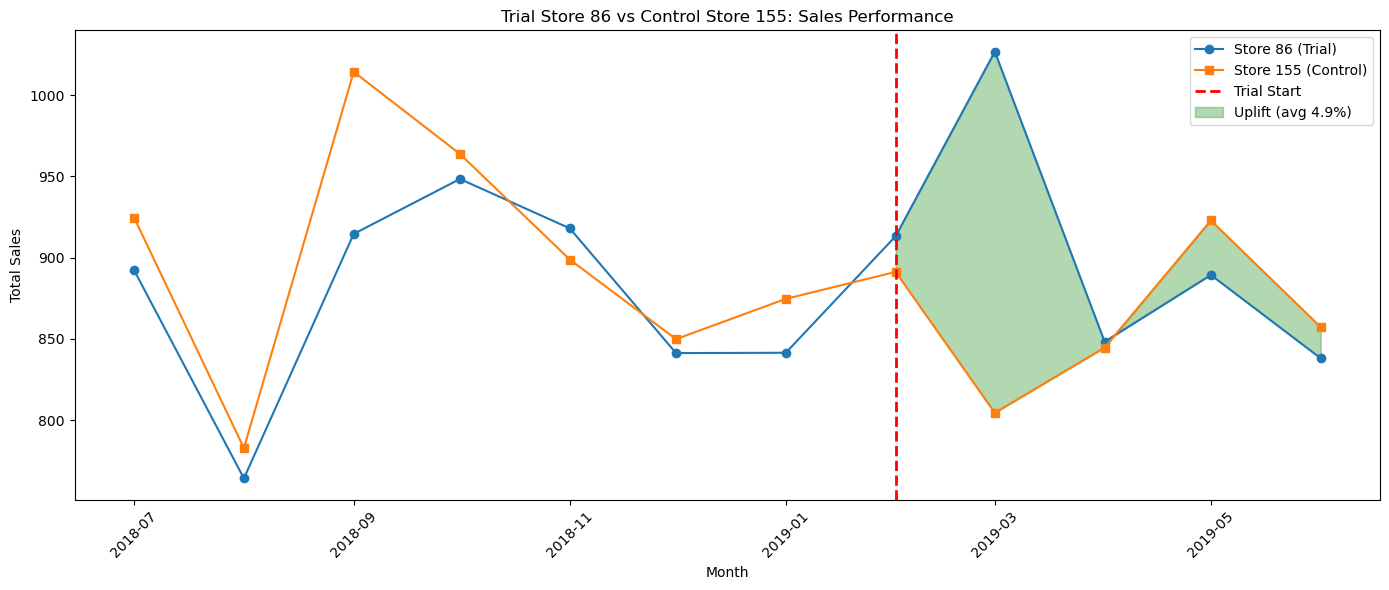

In [209]:
# 2. validate the performance
# filter post-intervention data (February 2019 and later)
post_trial_start = '2019-02-01'
post_trial_end = '2019-06-30'

post_data = df[(df['DATE'] >= post_trial_start) & (df['DATE'] <= post_trial_end)]
post_trial = post_data[post_data['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
post_control = post_data[post_data['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

# merge the post-intervention data
post_merged = pd.merge(post_trial, post_control, on='MONTH', suffixes=('_trial', '_control'))

# calculate Uplift (absolute and percentage)
post_merged['uplift_abs'] = post_merged['TOT_SALES_trial'] - post_merged['TOT_SALES_control']
post_merged['uplift_pct'] = (post_merged['uplift_abs'] / post_merged['TOT_SALES_control']) * 100

# calculate average Uplift
avg_uplift_pct = post_merged['uplift_pct'].mean()
avg_uplift_abs = post_merged['uplift_abs'].mean()

print(f"Average monthly absolute uplift after intervention: ${avg_uplift_abs:.2f}")
print(f"Average monthly relative uplift after intervention: {avg_uplift_pct:.2f}%")

# plot the full-period comparison chart (including pre- and post-intervention)
full_trial = df[df['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
full_control = df[df['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(full_trial['MONTH'], full_trial['TOT_SALES'], marker='o', label=f'Store {trial_store} (Trial)')
plt.plot(full_control['MONTH'], full_control['TOT_SALES'], marker='s', label=f'Store {control_store} (Control)')
plt.axvline(x=pd.to_datetime('2019-02-01'), color='red', linestyle='--', linewidth=2, label='Trial Start')
plt.fill_between(post_merged['MONTH'], 
                  post_merged['TOT_SALES_control'], 
                  post_merged['TOT_SALES_trial'], 
                  alpha=0.3, color='green', label=f'Uplift (avg {avg_uplift_pct:.1f}%)')
plt.title(f'Trial Store {trial_store} vs Control Store {control_store}: Sales Performance')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [210]:
# 3. Check the significance of the uplift using a simple t-test comparing the pre-intervention and post-intervention sales differences between the trial and control stores.

# T-test for pre- and post-intervention differences

# Difference before intervention
pre_diff = pre_merged['TOT_SALES_trial'] - pre_merged['TOT_SALES_control']

# Difference after intervention
post_diff = post_merged['TOT_SALES_trial'] - post_merged['TOT_SALES_control']

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(pre_diff, post_diff)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The difference before and after the intervention is significant, indicating the new layout is effective")
else:
    print("Conclusion: The difference before and after the intervention is not significant, so we cannot prove the new layout is effective")

t-statistic: -1.566
p-value: 0.1485
Conclusion: The difference before and after the intervention is not significant, so we cannot prove the new layout is effective


## For trial store 88

before intervention 88 vs control 237 sales correlation: 0.308
average percentage difference before intervention: 4.37%


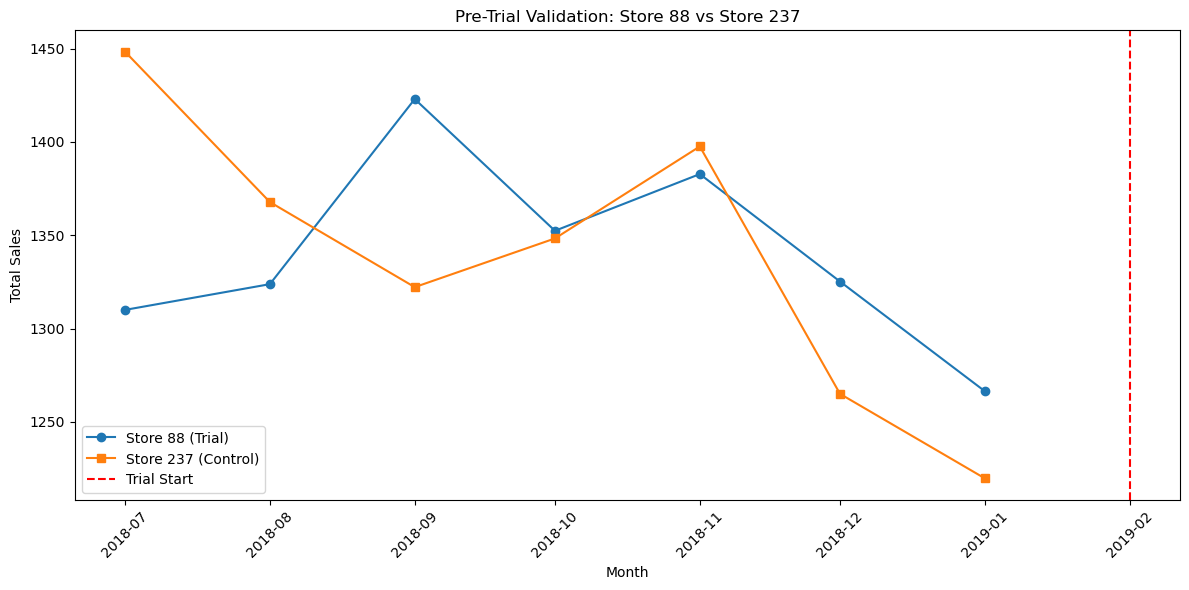

In [211]:
# Assume the trial store is 88, and you select the control store ranked first in the standardized metric (for example, 40,165,199,226,237).
trial_store = 88
control_store = 237 # tried five times from the top control stores ranked by standardized metric, 155 is the best one with the smallest standardized metric

# Filter pre-intervention data (assuming intervention starts from February 2019)
pre_trial_start = '2018-07-01'
pre_trial_end = '2019-01-31'

# Extract the monthly sales of the trial store and control store before the intervention
pre_data = df[(df['DATE'] >= pre_trial_start) & (df['DATE'] <= pre_trial_end)]
pre_trial = pre_data[pre_data['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
pre_control = pre_data[pre_data['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

# merge the trial and control data on MONTH
pre_merged = pd.merge(pre_trial, pre_control, on='MONTH', suffixes=('_trial', '_control'))

# Calculate correlation and percentage difference
correlation = pre_merged['TOT_SALES_trial'].corr(pre_merged['TOT_SALES_control'])
pre_merged['pct_diff'] = abs(pre_merged['TOT_SALES_trial'] - pre_merged['TOT_SALES_control']) / pre_merged['TOT_SALES_trial'] * 100
avg_pct_diff = pre_merged['pct_diff'].mean()

print(f"before intervention {trial_store} vs control {control_store} sales correlation: {correlation:.3f}")
print(f"average percentage difference before intervention: {avg_pct_diff:.2f}%")

# plot for validation
plt.figure(figsize=(12, 6))
plt.plot(pre_merged['MONTH'], pre_merged['TOT_SALES_trial'], marker='o', label=f'Store {trial_store} (Trial)')
plt.plot(pre_merged['MONTH'], pre_merged['TOT_SALES_control'], marker='s', label=f'Store {control_store} (Control)')
plt.axvline(x=pd.to_datetime('2019-02-01'), color='red', linestyle='--', label='Trial Start')
plt.title(f'Pre-Trial Validation: Store {trial_store} vs Store {control_store}')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average monthly absolute uplift after intervention: $155.83
Average monthly relative uplift after intervention: 13.16%


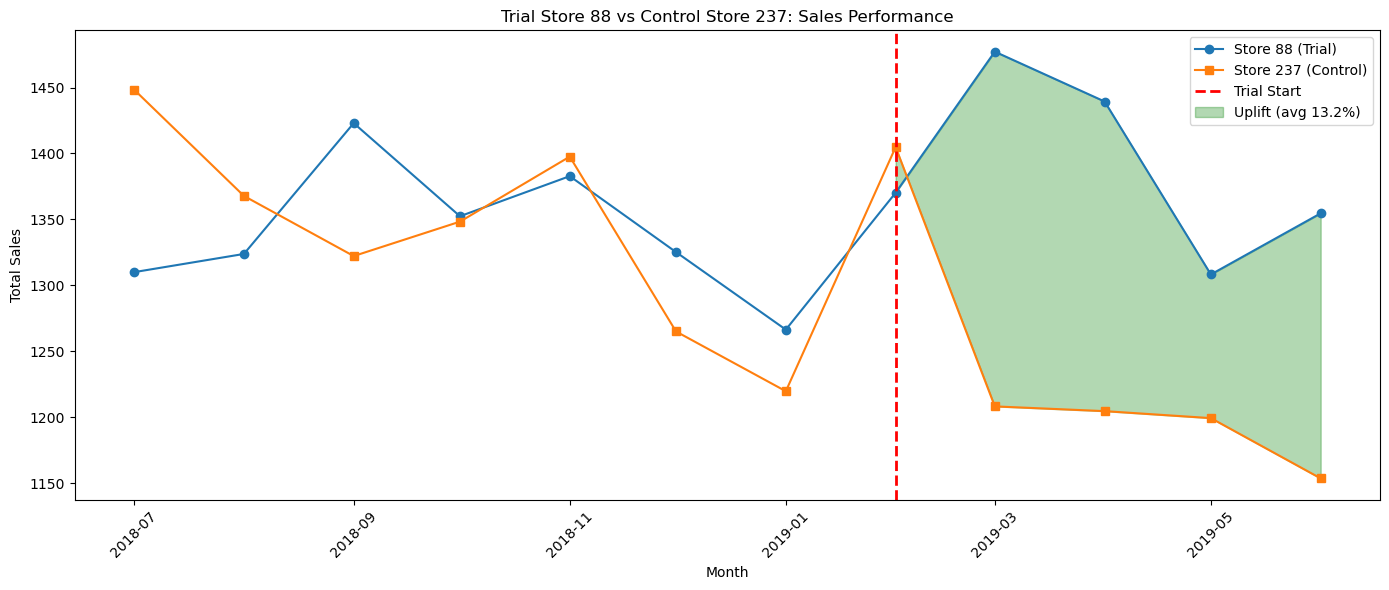

In [212]:
# 2. validate the performance
# filter post-intervention data (February 2019 and later)
post_trial_start = '2019-02-01'
post_trial_end = '2019-06-30'

post_data = df[(df['DATE'] >= post_trial_start) & (df['DATE'] <= post_trial_end)]
post_trial = post_data[post_data['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
post_control = post_data[post_data['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

# merge the post-intervention data
post_merged = pd.merge(post_trial, post_control, on='MONTH', suffixes=('_trial', '_control'))

# calculate Uplift (absolute and percentage)
post_merged['uplift_abs'] = post_merged['TOT_SALES_trial'] - post_merged['TOT_SALES_control']
post_merged['uplift_pct'] = (post_merged['uplift_abs'] / post_merged['TOT_SALES_control']) * 100

# calculate average Uplift
avg_uplift_pct = post_merged['uplift_pct'].mean()
avg_uplift_abs = post_merged['uplift_abs'].mean()

print(f"Average monthly absolute uplift after intervention: ${avg_uplift_abs:.2f}")
print(f"Average monthly relative uplift after intervention: {avg_uplift_pct:.2f}%")

# plot the full-period comparison chart (including pre- and post-intervention)
full_trial = df[df['STORE_NBR'] == trial_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()
full_control = df[df['STORE_NBR'] == control_store].groupby('MONTH')['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(full_trial['MONTH'], full_trial['TOT_SALES'], marker='o', label=f'Store {trial_store} (Trial)')
plt.plot(full_control['MONTH'], full_control['TOT_SALES'], marker='s', label=f'Store {control_store} (Control)')
plt.axvline(x=pd.to_datetime('2019-02-01'), color='red', linestyle='--', linewidth=2, label='Trial Start')
plt.fill_between(post_merged['MONTH'], 
                  post_merged['TOT_SALES_control'], 
                  post_merged['TOT_SALES_trial'], 
                  alpha=0.3, color='green', label=f'Uplift (avg {avg_uplift_pct:.1f}%)')
plt.title(f'Trial Store {trial_store} vs Control Store {control_store}: Sales Performance')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [213]:
# 3. Check the significance of the uplift using a simple t-test comparing the pre-intervention and post-intervention sales differences between the trial and control stores.

# T-test for pre- and post-intervention differences

# Difference before intervention
pre_diff = pre_merged['TOT_SALES_trial'] - pre_merged['TOT_SALES_control']

# Difference after intervention
post_diff = post_merged['TOT_SALES_trial'] - post_merged['TOT_SALES_control']

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(pre_diff, post_diff)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The difference before and after the intervention is significant, indicating the new layout is effective")
else:
    print("Conclusion: The difference before and after the intervention is not significant, so we cannot prove the new layout is effective")

t-statistic: -2.669
p-value: 0.0235
Conclusion: The difference before and after the intervention is significant, indicating the new layout is effective
